# Portfolio Value at Risk: Historical, Parametric, Monte Carlo and Bayesian Methods

When you hold a portfolio of assets, one of the most basic — and most important — questions you can ask is: *how much could I lose?* Value at Risk (VaR) answers this in a precise way: at a given confidence level (say, 95%), it estimates the maximum loss you'd expect over a given time horizon under normal market conditions.

This is not just an academic exercise. VaR is the standard risk metric used by banks, hedge funds, and regulators to size positions, set capital requirements, and decide how much risk is acceptable. But *how* you estimate it matters a lot — different methods make different assumptions, and those assumptions can lead to very different (and sometimes dangerously wrong) answers.

In this notebook, we compute the VaR of a 4-asset equity portfolio using four different approaches:

- **Historical VaR** — reads the risk directly from past data, with no distributional assumptions.
- **Parametric VaR** — assumes returns follow a log-normal model and derives VaR analytically.
- **Monte Carlo VaR** — simulates thousands of possible futures under the same model, without approximating the portfolio's distribution as normal.
- **Bayesian VaR** —  goes beyond the standard toolkit by also accounting for parameter uncertainty: how confident can we really be in our estimates of expected return and volatility, given the amount of data we have?

We then go one step further and use the same modeling framework to solve the **Markowitz portfolio problem**: given these estimates, what portfolio weights minimize risk for a target expected return?

The full mathematical derivation behind each method is available in [`MATH.md`](../MATH.md); here, we focus on running the methods on real market data and interpreting what they tell us — including how the amount of historical data available changes how much we should trust our own estimates.

*Note: while historical, parametric, and Monte Carlo VaR are standard industry methods, so is the Bayesian approach used here — the classical Normal-Inverse-Wishart posterior predictive method, implemented from scratch in this project, and aimed at explicitly quantifying parameter uncertainty, something the other three methods cannot do.*

### First, we select the tickers and the time period

In [2]:
import sys
sys.path.append("../src")
 
from data_loader import download_prices
 
tickers = ["YPF", "GGAL", "BMA", "PAM", "AGRO", "BIOX"]
start = "2025-08-01"
end = "2026-08-01"
data_location = "../data/precios.csv"
 
prices = download_prices(tickers, start, end)
prices.to_csv(data_location)
prices.head()
 


[*********************100%***********************]  6 of 6 completed


Ticker,AGRO,BIOX,BMA,GGAL,PAM,YPF
Date,,,,,,
2025-08-01,8.733309,3.47,65.162315,46.664803,74.209999,33.110001
2025-08-04,8.782873,3.58,66.788742,47.036907,74.629997,33.480000
2025-08-05,9.040610,3.59,70.099289,48.611164,77.519997,35.099998
2025-08-06,8.941482,3.37,72.861305,50.691093,82.660004,36.200001
2025-08-07,9.060436,3.32,71.244514,49.231327,77.209999,35.770000


### We use the class **FinancialContext** to manage the data

In [4]:
sys.path.append("../src")
from var_methods import FinancialContext

data_location = "../data/precios.csv"

fc = FinancialContext(data_location)

## Value at Risk: four methods, one portfolio

We now compute the VaR of our portfolio using the four methods derived in [`MATH.md`](../MATH.md), on the same uniform portfolio, at a 1-day horizon and 95% confidence level. Each method makes different assumptions about how returns behave — comparing them side by side is the core of this analysis.

We start by defining a uniform portfolio: an equal dollar amount invested in each of the 6 tickers.

In [5]:
import numpy as np
 
portfolio = np.ones(6)  # equal weights invested in each firm

### Historical VaR

Reads the risk directly from the empirical distribution of past portfolio P&L, with no assumption on the shape of returns — only that the past is representative of the future (see [`MATH.md`, Historical VaR](../MATH.md#historical-var)).

historical-VaR: 3.86%


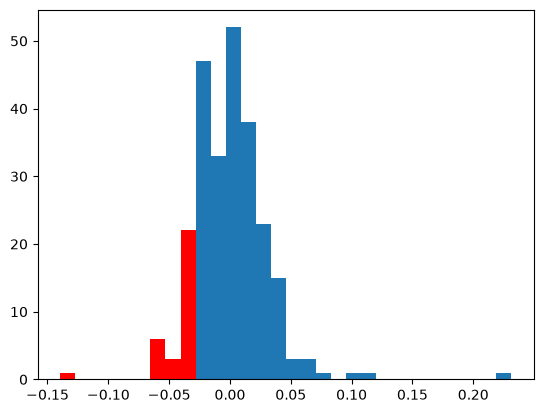

In [6]:
var_hist = fc.historical_VaR(portfolio, horizon=1, alpha=0.05, plot=True)

### Parametric VaR

Models the portfolio's log-returns as multivariate normal and derives VaR analytically from the resulting mean and standard deviation of the portfolio's value (see [`MATH.md`, Parametric approach](../MATH.md#parametric-approach)).

parametric-VaR: 5.04%


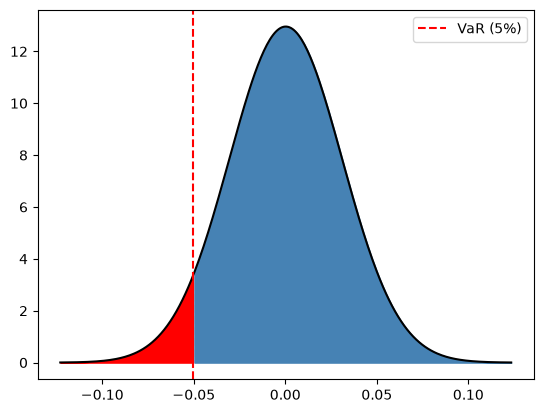

In [7]:
var_param = fc.parametric_VaR(portfolio, horizon=1, alpha=0.05, plot=True)

### Monte Carlo VaR

Simulates thousands of possible portfolio outcomes under the same log-normal model, without approximating the portfolio's own distribution as normal — this lets us check how good that normal approximation really is (see [`MATH.md`, Montecarlo approach](../MATH.md#monte-carlo-approach)).

montecarlo-VaR: 4.93%


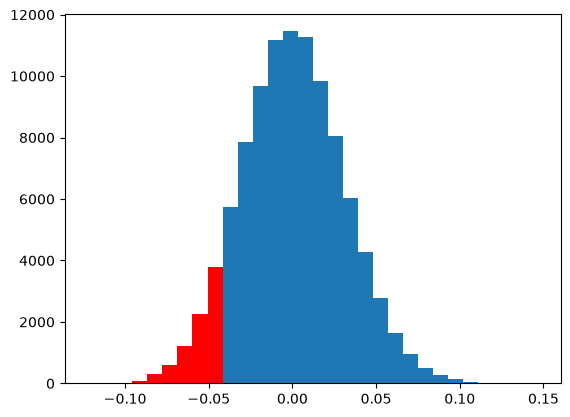

In [8]:
var_mc = fc.montecarlo_VaR(portfolio, horizon=1, alpha=0.05, N=100_000, seed=42, plot=True)

### Bayesian VaR

Goes a step further than the previous three methods: instead of treating the estimated mean and covariance as fixed, it treats them as uncertain, via a Normal-Inverse-Wishart posterior, and integrates over that uncertainty when simulating outcomes *(a classical Bayesian method, implemented from scratch in this project — see [`MATH.md`, Bayesian VaR](../MATH.md#bayesian-var))*.

bayesian-VaR: 5.06%


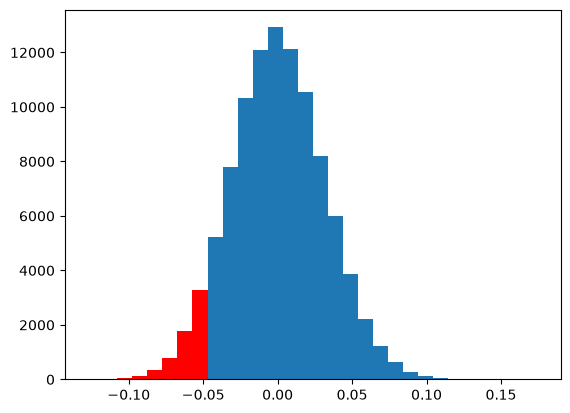

In [9]:
var_bayes = fc.bayesian_VaR(portfolio, horizon=1, alpha=0.05, N=100_000, seed=42, plot=True)

In [10]:
import pandas as pd
 
comparison = pd.Series({
    "Historical": var_hist,
    "Parametric": var_param,
    "Monte Carlo": var_mc,
    "Bayesian": var_bayes,
}, name="1-day VaR (95%)")
 
(comparison * 100).round(2).astype(str) + "%"


Historical     3.86%
Parametric     5.04%
Monte Carlo    4.93%
Bayesian       5.06%
Name: 1-day VaR (95%), dtype: str

### Which method should we trust? Backtesting

Computing VaR once, on today's data, tells us what each method estimates right now — it doesn't tell us which method has actually been *right* in the past. Backtesting answers that: we re-estimate VaR on a rolling window of historical data, step forward one day at a time, and check whether the realized loss ever exceeded what each method predicted.

Two hypothesis tests, standard across the risk management industry, are used to judge the result — implemented here via their **exact** forms rather than the classical asymptotic approximations:

- **A test on the proportion of failures** (in the spirit of Kupiec's POF
  test) asks whether the *rate* of VaR breaches matches what we'd expect
  at our chosen confidence level (e.g. close to 5% of days, for a 95%
  VaR) — too many breaches means the model understates risk; too few
  means it's needlessly conservative. Kupiec's original test relies on a
  likelihood-ratio statistic that is only approximately chi-squared for
  large samples; here we use an **exact binomial test** instead, which
  computes the true tail probability directly rather than relying on that
  large-sample approximation.
- **A test on the independence of breaches** (in the spirit of
  Christoffersen's test) asks whether breaches are scattered randomly
  through time, or cluster together — clustering would suggest the model
  fails to react when volatility itself changes. Christoffersen's
  original test also relies on a likelihood-ratio statistic over a
  two-state Markov chain; here we use **Fisher's exact test** on the 2×2
  table of consecutive breach/no-breach transitions instead.

In [11]:
from backtesting import rolling_back_tests

datos = pd.read_csv("../data/precios.csv")
seed = 42
 
pnl, VaR_estimations, binomial_pvalues, fisher_pvalues = rolling_back_tests(
    datos, portfolio, horizon=1, alpha=0.05, N=20_000,seed=42, window=100
)
# We needed to use a shorter window here than the strategy in the previous
# section (otherwise we would have had just one data point to test). We use
# the correct window in the next cell.

 
backtest_results = pd.DataFrame({
    "Exact binomial test p-value": binomial_pvalues,
    "Fisher's exact test p-value": fisher_pvalues,
}, index=["Historical", "Parametric", "Monte Carlo", "Bayesian"])
 
backtest_results.round(4)


Rolling backtest: 100%|██████████| 150/150 [00:07<00:00, 20.72it/s]


,Exact binomial test p-value,Fisher's exact test p-value
Historical,0.5707,0.4384
Parametric,0.4536,1.0000
Monte Carlo,0.4536,1.0000
Bayesian,0.4536,1.0000


As we can see, the p-values indicate that we cannot reject the hypothesis that the four methods behave as the tool says they should — every value is above 0.4.

However, we're only using one year of data here, which means the test doesn't have much statistical power: with so few rolling windows to work with, even a genuinely miscalibrated model might not produce a low enough p-value to be flagged. Moreover, we didn't use the window that we used in the analysis of VaR (because we would have just one data point)

Knowing this will take considerably longer to run, the next cell repeats the same analysis using 5 years of data instead with the right window.

In [12]:
# We download the data
tickers = ["YPF", "GGAL", "BMA", "PAM", "AGRO", "BIOX"]
start = "2021-08-01"
end = "2026-08-01"


prices_5y = download_prices(tickers,start,end)
prices_5y.to_csv("../data/precios_5y.csv")

[*********************100%***********************]  6 of 6 completed


In [13]:
datos_5y = pd.read_csv("../data/precios_5y.csv")

pnl_5y, VaR_estimations_5y, kupiec_pvalues_5y, christoffersen_pvalues_5y = rolling_back_tests(
    datos_5y, portfolio, horizon=1, alpha=0.05, N=100_000,seed=42, window=253
    # 253 is the exact window value we used for the headline VaR figures earlier
) # this is really slow, don't worry if it takes several minutes.
 
backtest_results_5y = pd.DataFrame({
    "Exact binomial test p-value": kupiec_pvalues_5y,
    "Fisher's exact test p-value": christoffersen_pvalues_5y,
}, index=["Historical", "Parametric", "Monte Carlo", "Bayesian"])
 
backtest_results_5y.round(4)

Rolling backtest: 100%|██████████| 1001/1001 [05:19<00:00,  3.13it/s]


,Exact binomial test p-value,Fisher's exact test p-value
Historical,0.8278,1.0000
Parametric,0.8846,0.5104
Monte Carlo,0.7715,0.5145
Bayesian,0.9422,0.5078


### Reading the 5-year result

Two things stand out.

**The point VaR estimates converge much more closely with 5 years of data.** With this much history, the four methods land much closer together than the roughly 1-point gap we saw with only 1 year of history. This is consistent with the outlier-driven explanation from earlier in the notebook: a handful of extreme days inflate a fitted Gaussian's standard deviation disproportionately, but that effect matters much less once it's diluted across five years of data instead of one.

**Using the correct estimation window, every method is very well calibrated.** The first version of this backtest used a 100-day rolling window to re-estimate each method's parameters at every step — much shorter than the ~1 trading year (253 days) used for the headline VaR figures earlier in this notebook, an inconsistency worth catching and fixing. Re-running the backtest with a matching ~253-day window gives p-values that are comfortably high across the board (0.51–1.00): the exact binomial test never drops below 0.77, and Fisher's exact test never drops below 0.5, with Historical hitting the model's expected breach rate almost exactly (Fisher p-value of 1.00). None of the Fisher p-values suggest breaches cluster in time for any method either. With an estimation window consistent with the rest of the analysis, all four methods hold up convincingly under formal statistical testing on this portfolio.

### Why do parametric, Monte Carlo, and Bayesian agree so closely?

These three methods are not independent ideas — they are three different *computational strategies* for the same underlying model: log-returns following a multivariate normal distribution (see [`MATH.md`](../MATH.md)). The parametric method solves for this model's implications in closed form; Monte Carlo solves it by simulation instead of algebra; and the Bayesian method solves essentially the same simulation, but additionally samples over parameter uncertainty. Since all three start from the *same phenomenological assumption* about how the market behaves, it would be surprising — and a sign of a bug — if they gave very different answers. Their agreement here is a consistency check on the implementation as much as it is a finding about the market.

### Why is the Bayesian estimate so close to the parametric and Monte Carlo values, yet still the most conservative?

With a full year of daily data (~250 observations), our estimates of the mean and covariance of returns are already fairly precise — there simply isn't that much residual uncertainty left to account for. This is why the Bayesian VaR lands so close to the parametric and Monte Carlo values: the posterior over $\mu$ and $\Sigma$ is tight, and sampling from it looks a lot like using the fixed point estimates the other methods rely on.

But "tight" is not the same as "zero". The Bayesian method is the only one of the four that explicitly propagates the fact that $\mu$ and $\Sigma$ are themselves estimated from a finite sample, not known exactly — and that residual uncertainty, however small, only ever adds risk, never subtracts it. This is why the Bayesian VaR consistently comes out as the most conservative of the three model-based methods, even with abundant data: it is answering a subtly different, more honest question — not *"what is the risk under my best point estimate of the market?"*, but *"what is the risk, given everything I don't know about my own estimate?"*

## Finding the best portfolio: Markowitz

So far, we've measured the risk of a fixed, uniform portfolio. But a natural question follows: could we do better? Given estimates of expected return and risk for each asset, is there a smarter way to combine them?

This is exactly the question Harry Markowitz asked in 1952, as a 25-year-old graduate student at the University of Chicago. His answer — now known as Modern Portfolio Theory — formalized something investors already knew intuitively ("don't put all your eggs in one basket") into rigorous mathematics: by combining assets that don't move in perfect lockstep, an investor can reduce a portfolio's overall risk without sacrificing expected return. The paper, titled simply *"Portfolio Selection"*, was published in the *Journal of Finance* and became the foundation of an entire field. Nearly four decades later, in 1990, Markowitz shared the Nobel Memorial Prize in Economic Sciences for this work, alongside Merton Miller and William Sharpe.

The full derivation of the classical Markowitz problem — solved here in closed form via Lagrange multipliers, rather than numerical optimization — is available in [`MATH.md`](../MATH.md#finding-the-best-portfolio--the-markowitz-problem). Below, we compute the optimal portfolio for a target expected return, using the exact same log-normal model behind our parametric VaR.

**A note on the solution**: this closed-form version of the problem does *not* restrict portfolio weights to be non-negative — the optimizer is free to assign a negative weight to an asset, which corresponds to a short position (betting against that asset). This matches the classical 1952 formulation; a long-only constraint (no shorting) would turn this into a numerical optimization problem instead of an algebraic one.

In [14]:
target_return = 1.15  # target gross portfolio value over the horizon (1.15 = +15% in one year)
 
optimal_weights = fc.markowitz_portfolio(target_return, horizon=365,verbose=False)
 
pd.Series(optimal_weights, index=fc.tickers, name="Optimal weight")


AGRO    0.348552
BIOX    0.273445
BMA    -0.011109
GGAL   -0.074059
PAM     0.393834
YPF     0.069337
Name: Optimal weight, dtype: float64

### Reading the optimal portfolio

For a 15% annual expected return target, the optimizer suggests:

| Asset | Weight |
|---|---|
| PAM  | 39.4%  |
| AGRO | 34.9%  |
| BIOX | 27.3%  |
| YPF  | 6.9%   |
| GGAL | **-7.4%** |
| BMA  | **-1.1%** |

Two things stand out. The portfolio is far from diversified — PAM, AGRO, and BIOX alone add up to over 100% of capital, funded by short positions in the other two names. And GGAL and BMA get **negative weights**: short positions. This doesn't mean the model expects them to fall — since portfolio variance depends on the full covariance structure (Eq. K.2, `MATH.md`), shorting an asset correlated with the rest can *reduce* overall volatility regardless of its own expected return. It's a volatility-hedging effect, not a directional bet — a genuine feature of mean-variance optimization.

Since we imposed no non-negativity constraint (Eq. K.3, `MATH.md`), the closed-form solution is free to reach for this kind of position; a long-only mandate would floor it at zero and require numerical optimization instead.

## Conclusions

This repository implements a full portfolio risk toolkit from first principles: four independent VaR methods (historical, parametric, Monte Carlo, and a Bayesian method built on the classical Normal-Inverse-Wishart model), a closed-form solution to the classical Markowitz problem, and a `MATH.md` document deriving every formula used, from the log-normal price model up to the Bayesian posterior. The four methods aren't just run in isolation — they're cross-validated against each other, and the backtest above shows the framework doing exactly what the theory predicts when the amount of data available to it changes.

- **Parametric, Monte Carlo, and Bayesian VaR agree closely** — expected,
  since all three interpret market dynamics through the same log-normal
  model; only *how* they compute the answer differs.
- **The Bayesian method is consistently the
  most conservative** among the three model-based methods. With 1 year of
  data (~250 observations) the gap is already small, since the posterior
  over $\mu$ and $\Sigma$ is fairly tight; going to 5 years of data
  narrows the point estimates of all four methods toward each other even
  further, consistent with residual parameter uncertainty shrinking as
  more data dilutes the influence of any handful of extreme days.

**Limitations**: every model here assumes log-returns are multivariate normal and i.i.d. over time; the historical method instead assumes the past is representative of the future. Neither assumption is guaranteed to hold, especially for Argentine equities prone to sharp, news-driven moves. We also only tested two amounts of history (1 year and 5 years) on one portfolio; a systematic sweep across window lengths would make the data-quantity finding above more rigorous.

**Possible next steps**: add CVaR alongside VaR; sweep the estimation window across intermediate lengths (e.g. 1, 3, 6, 12 months) to trace out how Bayesian conservatism actually decays with sample size, rather than only comparing two endpoints.